# Pandas快速入门与实践

## Series基本操作

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置支持中文的字体（Windows 系统常用 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者 ['Microsoft YaHei']

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

### 数据选择与访问

In [2]:
import numpy as np
import pandas as pd

#np.random.seed(96)  # 固定随机种子
#v = np.random.randint(1, 10, size=10)   # 生成于1到10之间的10个随机正整数
#print(v)

s = pd.Series([5, 7, 5, None, 9, np.nan, 3, 7, 7, np.nan, 3, 8])
print(s)   # 打印整个Series，元素多的时候慎用
print(s.head())  # 显示序列的前5个元素
print(s.tail(3))  # 显示序列的后3个元素
print(s[1])  # 打印索引1的元素值
print(s.iloc[1])  # 打印索引1的元素值
print(s[[1, 11]])  # 打印索引1和11元素值
print(s[1:5])  # 打印索引1到5之间的元素值，不包括索引5
print(s[s>7])  # 打印元素值打7的元素

0     5.0
1     7.0
2     5.0
3     NaN
4     9.0
5     NaN
6     3.0
7     7.0
8     7.0
9     NaN
10    3.0
11    8.0
dtype: float64
0    5.0
1    7.0
2    5.0
3    NaN
4    9.0
dtype: float64
9     NaN
10    3.0
11    8.0
dtype: float64
7.0
7.0
1     7.0
11    8.0
dtype: float64
1    7.0
2    5.0
3    NaN
4    9.0
dtype: float64
4     9.0
11    8.0
dtype: float64


### 数据清洗操作

In [3]:
import numpy as np
import pandas as pd

s = pd.Series([5, 7, 5, 2, 9, np.nan, 3, 7, 7, np.nan, 3, 8])
print(s.info())  # 打印Series信息
print('--errtewtr')
print(s.isna())  # 返回一个布尔型Series，标记每个元素是否为NaN

print(s.dropna())  # 删除缺失值，返回视图（不对原Series进行操作）
print(s.fillna(10))  # 用指定的值填充
print(s)
print('--->')
print(s.interpolate())  # 插值填充，返回视图

print(s.duplicated())   # 检查重复值
print(s.drop_duplicates())  # 移除重复值，每个元素值仅保留一份
s.interpolate().drop_duplicates()

<class 'pandas.Series'>
RangeIndex: 12 entries, 0 to 11
Series name: None
Non-Null Count  Dtype  
--------------  -----  
10 non-null     float64
dtypes: float64(1)
memory usage: 228.0 bytes
None
--errtewtr
0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9      True
10    False
11    False
dtype: bool
0     5.0
1     7.0
2     5.0
3     2.0
4     9.0
6     3.0
7     7.0
8     7.0
10    3.0
11    8.0
dtype: float64
0      5.0
1      7.0
2      5.0
3      2.0
4      9.0
5     10.0
6      3.0
7      7.0
8      7.0
9     10.0
10     3.0
11     8.0
dtype: float64
0     5.0
1     7.0
2     5.0
3     2.0
4     9.0
5     NaN
6     3.0
7     7.0
8     7.0
9     NaN
10    3.0
11    8.0
dtype: float64
--->
0     5.0
1     7.0
2     5.0
3     2.0
4     9.0
5     6.0
6     3.0
7     7.0
8     7.0
9     5.0
10    3.0
11    8.0
dtype: float64
0     False
1     False
2      True
3     False
4     False
5     False
6     False
7      True
8   

0     5.0
1     7.0
3     2.0
4     9.0
5     6.0
6     3.0
11    8.0
dtype: float64

### 统计与聚合操作

In [4]:
import numpy as np
import pandas as pd

s = pd.Series([5, 7, 5, 2, 9, np.nan, 3, 7, 7, np.nan, 3, 8])
print(s.sum())   # 求和
print(s.dropna().sum())  # 非缺失值求和
print(s.dropna().median())  # 非缺失值求中位数
print(s.dropna().quantile())  # 求四分之一分位数
print(s.dropna().unique())  # 返回不包含NaN的惟一值元素列表

s_dates = pd.Series(["2022-12-1", "2023-07-21", "2024-06-01", "2025-07-19"])   # 生成日期Series
print('\n1##\n',s_dates)
s_dates = pd.to_datetime(s_dates)   # 转换为Pandas的日期格式
print('2##\n',s_dates)

print('\n3##\n',s_dates.dt.year)   # 打印年份
print(s_dates.dt.month) # 打印月份
print(s_dates.dt.day)   # 打印Day of Month
print(s_dates.dt.weekday)  # 打印Day of Week

56.0
56.0
6.0
6.0
[5. 7. 2. 9. 3. 8.]

1##
 0     2022-12-1
1    2023-07-21
2    2024-06-01
3    2025-07-19
dtype: str
2##
 0   2022-12-01
1   2023-07-21
2   2024-06-01
3   2025-07-19
dtype: datetime64[us]

3##
 0    2022
1    2023
2    2024
3    2025
dtype: int32
0    12
1     7
2     6
3     7
dtype: int32
0     1
1    21
2     1
3    19
dtype: int32
0    3
1    4
2    5
3    5
dtype: int32


### 运算


In [5]:
import pandas as pd
import numpy as np
 
s1 = pd.Series(np.arange(1,16)) # 1...15
s2 = pd.Series(np.ones(15)) # 个1

## 广播
print(f'标量1加15个series', 1 +s1) # 2...16


## 维 运算
print(f'15个1加15个series', s1 +s2) # 2...16
print(f'16个1加15个series',  s2 + pd.Series(np.ones(16)) ) # 2...16..NaN

# 排序
print('\n按值排序: \n',s1.sort_values(ascending=False))
print('\n按索引排序: \n',s1.sort_index(ascending=False))

s3 = pd.Series([90,10,50,20,50])
print('\n按值排名排序: \n',s3.rank())

# 先后台排序 10 20 50 50 90
# 排名       1 2  3   4  5
# avg       1  2 (3+4)/2=3.5 5
# min       1  2  3   3 5
# max       1  2  4   4 5
# first     1  2  3   4  5

# 5 个人 两个人的分数都是 50 分，不同方法只是求相同分数人怎么排名的
# 心宽策略 min, 分数一样就并列第3吧
# 严格策略 max, 排在咱们前面的有 10、20 和另一个 50, 并列第4
# 折中策略 avg, 咱们平均一下，算第 3.5 名吧
# 先到先得策略 first, 不管分数一样不一样，谁先加入队伍，谁就是第 2 名，后来的那个只能是第 3

data = pd.Series([90,10,50,20,50])
pd.DataFrame({
    '原数据': data,
    'average (默认)': data.rank(method='average'),
    'min': data.rank(method='min'),
    'max': data.rank(method='max'),
    'first': data.rank(method='first')
})



标量1加15个series 0      2
1      3
2      4
3      5
4      6
5      7
6      8
7      9
8     10
9     11
10    12
11    13
12    14
13    15
14    16
dtype: int64
15个1加15个series 0      2.0
1      3.0
2      4.0
3      5.0
4      6.0
5      7.0
6      8.0
7      9.0
8     10.0
9     11.0
10    12.0
11    13.0
12    14.0
13    15.0
14    16.0
dtype: float64
16个1加15个series 0     2.0
1     2.0
2     2.0
3     2.0
4     2.0
5     2.0
6     2.0
7     2.0
8     2.0
9     2.0
10    2.0
11    2.0
12    2.0
13    2.0
14    2.0
15    NaN
dtype: float64

按值排序: 
 14    15
13    14
12    13
11    12
10    11
9     10
8      9
7      8
6      7
5      6
4      5
3      4
2      3
1      2
0      1
dtype: int64

按索引排序: 
 14    15
13    14
12    13
11    12
10    11
9     10
8      9
7      8
6      7
5      6
4      5
3      4
2      3
1      2
0      1
dtype: int64

按值排名排序: 
 0    5.0
1    1.0
2    3.5
3    2.0
4    3.5
dtype: float64


,原数据,average (默认),min,max,first
0,90,5.0,5.0,5.0,5.0
1,10,1.0,1.0,1.0,1.0
2,50,3.5,3.0,4.0,3.0
3,20,2.0,2.0,2.0,2.0
4,50,3.5,3.0,4.0,4.0


### Series绘图操作

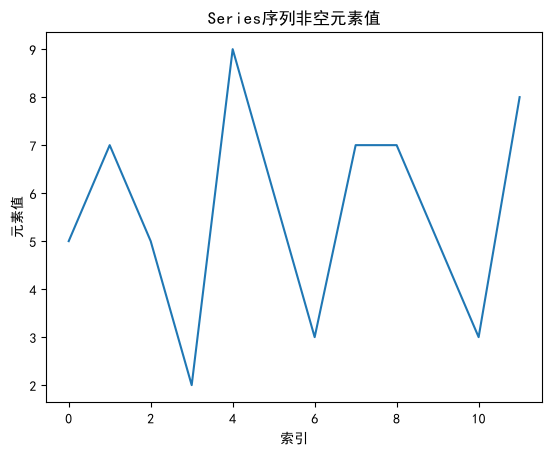

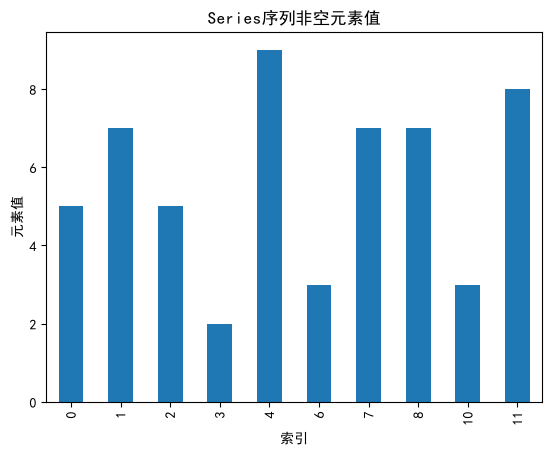

<BarContainer object of 10 artists>

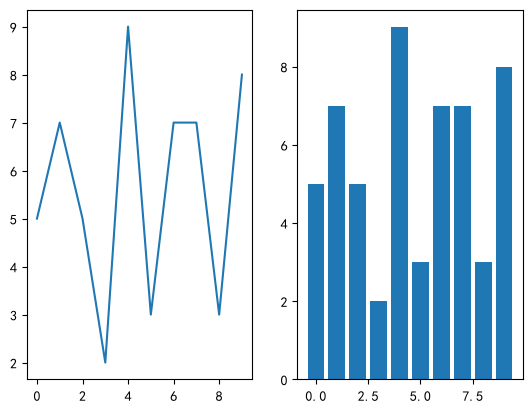

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s = pd.Series([5, 7, 5, 2, 9, np.nan, 3, 7, 7, np.nan, 3, 8])

fig = s.dropna().plot(kind="line")
plt.title("Series序列非空元素值")
plt.xlabel("索引")
plt.ylabel("元素值")
plt.show()

fig = s.dropna().plot(kind="bar")
plt.title("Series序列非空元素值")
plt.xlabel("索引")
plt.ylabel("元素值")
plt.show()


 
# 直接绘制
fig, ax = plt.subplots(1,2)

x = np.arange(0,s.dropna().size)
ax[0].plot(x, s.dropna())

ax[1].bar(x,s.dropna())

### 应用函数

In [7]:
# 创建 Series
s = pd.Series(['cat', 'dog', 'bird', 'tigger',np.nan,None])

# 定义映射字典
mapping = {'cat': '猫', 'dog': '狗', 'bird': '鸟'}

# 使用map()
print(f"使用map()进行字典映射：\n{s.map(mapping)}")
# 使用map()，忽略缺失值
print(f"使用map()进行字典映射：\n{s.map(mapping, na_action='ignore')}")

# 创建第二个 Series
s2 = pd.Series([1, 2, None, 3, 4])

# 使用apply()映射
result_apply = s2.apply(lambda x: x ** 2)
print(f"使用apply()应用函数：\n{result_apply}")

# 使用apply()映射，模拟忽略缺失值
result_apply = s2.apply(lambda x: x ** 2 if pd.notnull(x) else x)
print(f"使用apply()应用函数：\n{result_apply}")

使用map()进行字典映射：
0      猫
1      狗
2      鸟
3    NaN
4    NaN
5    NaN
dtype: str
使用map()进行字典映射：
0      猫
1      狗
2      鸟
3    NaN
4    NaN
5    NaN
dtype: str
使用apply()应用函数：
0     1.0
1     4.0
2     NaN
3     9.0
4    16.0
dtype: float64
使用apply()应用函数：
0     1.0
1     4.0
2     NaN
3     9.0
4    16.0
dtype: float64


## DataFrame实践

### 基于数据集创建DataFrame

In [30]:
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns # 监督学习

# 加载 tips 数据集
tips = sns.load_dataset('tips')
df = pd.DataFrame(tips)  # 确保是 Pandas DataFrame
print(f"Seaborn的tip数据集预览：\n {df.head()}")

# 列操作
print(df['tip'].head())
print('\n===\n',df['tip'].dtype)

# 加载Iris数据集
iris = load_iris()

# 创建DataFrame，未指定列名称
df = pd.DataFrame(data=iris.data)
print(f"\nScikit-Learn的iris数据集预览：\n {df.head()}")

# 创建DataFrame，指定列名称为Feature名称
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target  # 添加目标列
df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})  # 将目标值映射为类别名称

# 打印 DataFrame 前几行以确认结构
print(f"\nScikit-Learn的iris数据集预览(使用Feature Name作为列名称，并添加了target字段)：\n {df.head()}")

Seaborn的tip数据集预览：
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

===
 float64

Scikit-Learn的iris数据集预览：
      0    1    2    3
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2

Scikit-Learn的iris数据集预览(使用Feature Name作为列名称，并添加了target字段)：
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6             

### 数据的基本操作

In [36]:
import pandas as pd
import seaborn as sns

# 加载 tips 数据集
tips = sns.load_dataset('tips')
df = pd.DataFrame(tips)
print("\nDataFrame的数据信息:")

df.info()
print('\n')

print(f"后5行数据：\n{df.tail()}")
print(f"\n索引信息：\n{df.index}")
print(f"\n列名信息：\n{df.columns}")
print(f"\n底层的NumPy数组（前3行）：\n{df.head(3).values}")
# print(f"\n底层的NumPy数组（前3行）：\n{df.values[:3]}")
print(f"\n各列数据类型：\n{df.dtypes}")
print(f"\nDataFrame表格的形状：\n{df.shape}")




DataFrame的数据信息:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


后5行数据：
     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

索引信息：
RangeIndex(start=0, stop=244, step=1)

列名信息：
Index(['total_bill', 'tip', 'sex', 'smoker', '

### 聚合操作

In [ ]:
import pandas as pd
df = pd.DataFrame([[1,2,3,4],[5,6,7,8],[10,20,30,40]], index=['row0', 'row1', 'row2'], columns=['col0', 'col1', 'col2', 'col3'])
print(df.head())

# 对所有行或所有列求和：df.sum(axis=0|axis=1)
print(f"对列求和（以行为轴）:\n{df.sum(axis=0)}")
print(f"对行求和（以列为轴）:\n{df.sum(axis=1)}")

# 对指定列求和：df['col_name'].sum()
print(f"对指定的列求和：\n{df['col0'].sum()}")

# 对指定的行（使用行标签）求和：df.loc['row_label'].sum()
print(f"对指定的行求和：\n{df.loc['row0'].sum()}")

# 对指定的行（使用行索引）求和：df.iloc[index].sum()
print(f"对指定的行求和：\n{df.iloc[1].sum()}")

print("对指定范围内的多行求和")
print(df.iloc[[0, 1]].sum(axis=1))

print("对指定范围内的多行求和之后，再求总和")
print(df.iloc[[0, 1]].sum(axis=1).sum())

# 求所有数值列之间的相关系数
print("\n所有数值列之间的相关系数:")
print(df.corr())

# 指定的两个列之间的相关系数
print("\n指定的两个数值列之间的相关系数:")
print(df['col1'].corr(df['col2']))

# 求所有数值列之间的协方差
print("\n所有数值列之间的协方差:")
print(df.cov())

# 指定的两个列之间的协方差
print("\n指定的两个数值列之间的协方差:")
print(df['col1'].cov(df['col2']))

### 相关系数矩阵和协方差矩阵


=== 相关系数矩阵（Pearson） ===
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


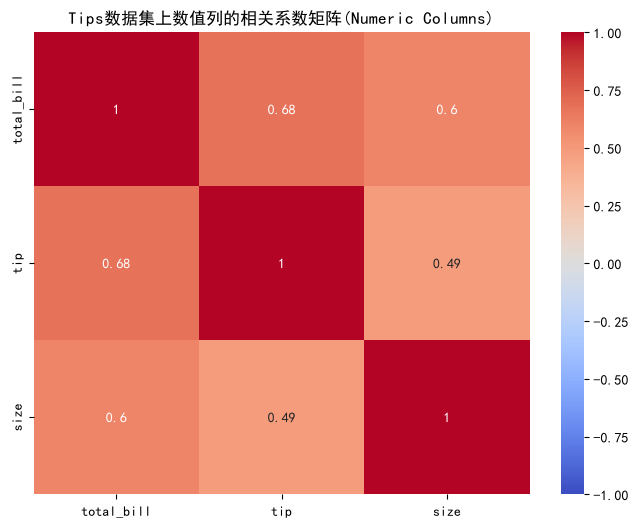

In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 加载 tips 数据集
tips = sns.load_dataset('tips')
df = pd.DataFrame(tips)  # 转换为 Pandas DataFrame

# 选择数值列
numeric_cols = ['total_bill', 'tip', 'size']
df_numeric = df[numeric_cols]

# 计算相关系数矩阵（Pearson）
print("\n=== 相关系数矩阵（Pearson） ===")
corr_matrix = df_numeric.corr(method='pearson')
print(corr_matrix)

# # 计算协方差矩阵
# print("\n=== 协方差矩阵 ===")
# cov_matrix = df_numeric.cov()
# print(cov_matrix)

# 可视化相关系数矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Tips数据集上数值列的相关系数矩阵(Numeric Columns)')
plt.show()

### 分组聚合功能示例

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 加载 tips 数据集
tips = sns.load_dataset('tips')
df = pd.DataFrame(tips)

# 单列分组：按 day 分组
print("\n=== 按星期分组的平均账单和小费 ===")
day_group = df.groupby('day')[['total_bill', 'tip']].mean()
print(day_group)

# 多个聚合函数
print("\n=== 按星期分组的多种统计（均值、总和、计数） ===")
day_agg = df.groupby('day')[['total_bill', 'tip']].agg(['mean', 'sum', 'count'])
print(day_agg)

# 多列分组：按 day 和 time 分组
print("\n=== 按星期和就餐时间分组的平均账单和小费 ===")
day_time_group = df.groupby(['day', 'time'])[['total_bill', 'tip']].mean()
print(day_time_group)

# 自定义聚合函数：计算小费比例均值
print("\n=== 按星期分组的小费比例均值 ===")
def tip_ratio_mean(group):
    return (group['tip'] / group['total_bill']).mean()
tip_ratio = df.groupby('day').apply(tip_ratio_mean)
print(tip_ratio)

# 可视化
print("\n=== 可视化：按星期分组的平均账单和小费 ===")
day_group.plot(kind='bar', figsize=(10, 6))
plt.title('Average Total Bill and Tip by Day')
plt.xlabel('Day')
plt.ylabel('Amount ($)')
plt.legend(['Total Bill', 'Tip'])
plt.show()

### 数据清洗示例

In [3]:
import pandas as pd
from sklearn.datasets import load_iris # 不重复
import numpy as np 

# 加载 iris 数据集
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names) # 数值索引
df['species'] = iris.target_names[iris.target]  # 添加种类列 

# 查看基本信息
print("=== 数据集基本信息 ===")
print(df.info())
print("\n前 5 行数据：")
print(df.head())

# 创建脏数据副本
df_dirty = df.copy() # 不修改

# 1. 随机引入缺失值
np.random.seed(42) # 42 种子，方便重复多次随机数一样
mask = np.random.choice([True, False], size=df.shape, p=[0.1, 0.9])  # False比率 10% 概率缺失 
df_dirty[mask] = np.nan #找到10%替换nan

# 2. 添加重复行
df_duplicate = pd.concat([df_dirty, df_dirty.iloc[:5]], ignore_index=True)

# 3. 引入异常值（将部分 sepal length 设置为负值或极值）
df_dirty.loc[0:2, 'sepal length (cm)'] = -1.0  # 负值异常
df_dirty.loc[3, 'sepal length (cm)'] = 100.0   # 极值异常

# 4. 引入不一致的种类名称
df_dirty.loc[5:7, 'species'] = 'SETOSA'  # 大写不一致

# 查看脏数据
print("\n=== 脏数据前 10 行 ===")
print(df_dirty.head(10))
print("\n脏数据信息：")
print(df_dirty.info())

# 检查缺失值
print("\n=== 缺失值统计 ===")
print(df_dirty.isnull().sum())

# 填充数值列的缺失值（使用均值）
df_cleaned = df_dirty.copy()
numeric_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean()) # 列取出，将nan替换成当前行的均值

# 填充分类列的缺失值（使用众数）
df_cleaned['species'] = df_cleaned['species'].fillna(df_cleaned['species'].mode()[0]) # 列取出，将nan替换成当前行的众数

print("\n=== 填充后缺失值统计 ===")
print(df_cleaned.isnull().sum())

# 检查重复行（基于 df_duplicate）
print("\n=== 重复行数量 ===")
print(df_duplicate.duplicated().sum())

# 删除重复行
df_duplicate_cleaned = df_duplicate.drop_duplicates()
print("\n=== 删除重复行后的形状 ===")
print(df_duplicate_cleaned.shape)

# 检测负值异常
print("\n=== 负值异常（sepal length） ===")
print(df_cleaned[df_cleaned['sepal length (cm)'] < 0])

# 替换负值为均值
mean_sepal_length = df_cleaned['sepal length (cm)'][df_cleaned['sepal length (cm)'] > 0].mean()
df_cleaned.loc[df_cleaned['sepal length (cm)'] < 0, 'sepal length (cm)'] = mean_sepal_length

# 检测极值（例如，sepal length > 10）
print("\n=== 极值异常（sepal length） ===")
print(df_cleaned[df_cleaned['sepal length (cm)'] > 10])

# 替换极值为均值
df_cleaned.loc[df_cleaned['sepal length (cm)'] > 10, 'sepal length (cm)'] = mean_sepal_length

print("\n=== 异常值处理后前 5 行 ===")
print(df_cleaned.head())

=== 数据集基本信息 ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

前 5 行数据：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  se

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# 加载iris数据集
# 使用scikit-learn库加载经典的iris(鸢尾花) 数据集。
# iris数据集包含4个特征 (萼片长度、萼片宽度、花瓣长度、花瓣宽度) 和3种鸢尾花类别。
iris = load_iris()
# 将 iris 数据转换为 Pandas DataFrame。
# data=iris.data 包含了数值特征。
# columns=iris.feature_names 设置了 DataFrame 的列名。
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# 将鸢尾花的类别信息 (target) 添加为新列 'species'。
# iris.target 是数值型类别 (0, 1, 2)，iris.target_names 提供了对应的名称 ('setosa', 'versicolor', 'virginica')。
df['species'] = iris.target_names[iris.target]

# 创建脏数据
# 复制原始 DataFrame，以便在上面制造“脏数据”而不影响原始数据。
df_dirty = df.copy()
# 设置随机种子，确保每次运行代码时生成的随机数相同，从而使脏数据生成过程可复现。
np.random.seed(42)
# 随机生成一个布尔掩码，用于在 DataFrame 中随机选择一些位置。
# np.random.choice([True, False], size=df.shape, p=[0.1, 0.9]) 表示有10%的概率为True，90%的概率为False。
# 这样，大约10%的数据点将被选中用于制造缺失值。
mask = np.random.choice([True, False], size=df.shape, p=[0.1, 0.9])
# 将掩码为True的位置的数据替换为NaN (Not a Number)，即缺失值。
df_dirty[mask] = np.nan
# 在 'sepal length (cm)' 列的第0到2行 (包含 0、1、2 行) 引入异常的负值 (-1.0)。
df_dirty.loc[0:2, 'sepal length (cm)'] = -1.0
# 在 'sepal length (cm)' 列的第3行引入异常的过大值 (100.0)。
df_dirty.loc[3, 'sepal length (cm)'] = 100.0
# 在 'species' 列的第5到7行 (包含5、6、7行) 引入大小写不一致的类别值 ('SETOSA')。
df_dirty.loc[5:7, 'species'] = 'SETOSA'
# 通过将df_dirty的前5行再次添加到df_dirty的末尾来创建重复行，模拟重复数据。
df_duplicate = pd.concat([df_dirty, df_dirty.iloc[:5]], ignore_index=True)

# 数据清洗
# 复制包含脏数据的 DataFrame，用于进行清洗操作，保留原始脏数据。
df_cleaned = df_dirty.copy()

# 1. 处理缺失值
# 定义数值类型的列名列表，这些列通常需要进行数值填充。
numeric_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
# 遍历数值列，使用该列的均值填充其中的 NaN 值。
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())
# 对于非数值 (类别) 列 'species'，使用众数 (出现次数最多的值) 填充其中的 NaN 值。
# .mode()[0] 是因为 mode() 可能返回多个众数，我们取第一个。
df_cleaned['species'] = df_cleaned['species'].fillna(df_cleaned['species'].mode()[0])

# 2. 处理重复值
# 对包含重复数据的DataFrame (df_duplicate) 进行去重操作。
# 默认情况下，drop_duplicates()会删除所有重复行，只保留第一次出现的行。
df_duplicate_cleaned = df_duplicate.drop_duplicates()

# 3. 处理异常值
# 计算 'sepal length (cm)' 列中所有大于0的值的均值，用于替换异常值。
# 这样可以避免负值或极大的异常值影响均值的计算。
mean_sepal_length = df_cleaned['sepal length (cm)'][df_cleaned['sepal length (cm)'] > 0].mean()
# 识别并替换 'sepal length (cm)' 列中小于0的异常值，将其替换为之前计算的均值。
df_cleaned.loc[df_cleaned['sepal length (cm)'] < 0, 'sepal length (cm)'] = mean_sepal_length
# 识别并替换 'sepal length (cm)' 列中大于10的异常值 (例如 100.0)，将其替换为均值。
# 这里假设萼片长度通常不会超过10厘米。
df_cleaned.loc[df_cleaned['sepal length (cm)'] > 10, 'sepal length (cm)'] = mean_sepal_length

# 4. 数据类型转换
# 将 'species' 列的数据类型转换为 'category' (类别型)。
# 类别型数据类型在存储和处理具有有限数量唯一值的列时更高效，并能提供更好的性能。
df_cleaned['species'] = df_cleaned['species'].astype('category')

# 5. 值替换
# 将 'species' 列中所有值为 'SETOSA' (大写) 的条目替换为 'setosa' (小写)，实现大小写统一。
df_cleaned['species'] = df_cleaned['species'].replace('SETOSA', 'setosa')

# 查看清洗结果
print("\n=== 清洗后数据信息 ===")
# 打印清洗后 DataFrame 的摘要信息，包括每列的非空值数量和数据类型，确认缺失值是否已处理。
print(df_cleaned.info())
print("\n=== 清洗后前5行 ===")
# 打印清洗后 DataFrame 的前 5 行，以便快速查看数据清洗效果。
print(df_cleaned.head())
print("\n=== 清洗后重复行数量 ===")
# 打印 df_duplicate_cleaned 中是否存在重复行。期望结果为 0。
print(df_duplicate_cleaned.duplicated().sum())
print("\n=== 清洗后species唯一值 ===")
# 打印 'species' 列的所有唯一值，确认大小写统一和异常值是否已处理。
print(df_cleaned['species'].unique())

## DataFrame的高级功能示例

### DF的合并与连接

In [4]:
import pandas as pd
import numpy as np

# 创建两个示例 DataFrame
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3'],
                    'B': ['B0', 'B1', 'B2', 'B3'],
                    'C': ['C0', 'C1', 'C2', 'C3'],
                    'D': ['D0', 'D1', 'D2', 'D3']},
                   index=[0, 1, 2, 3])

df2 = pd.DataFrame({'A': ['A4', 'A5', 'A6', 'A7'],
                    'B': ['B4', 'B5', 'B6', 'B7'],
                    'C': ['C4', 'C5', 'C6', 'C7'],
                    'D': ['D4', 'D5', 'D6', 'D7']},
                   index=[4, 5, 6, 7])

df3 = pd.DataFrame({'F': ['F0', 'F1', 'F2', 'F3'],
                    'G': ['G0', 'G1', 'G2', 'G3'],
                    'H': ['H0', 'H1', 'H2', 'H3'],
                    'I': ['I0', 'I1', 'I2', 'I3']},
                   index=[0, 1, 2, 3])

print("df1:")
print(df1)
print("\ndf2:")
print(df2)
print("\ndf3:")
print(df3)

df1:
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3

df2:
    A   B   C   D
4  A4  B4  C4  D4
5  A5  B5  C5  D5
6  A6  B6  C6  D6
7  A7  B7  C7  D7

df3:
    F   G   H   I
0  F0  G0  H0  I0
1  F1  G1  H1  I1
2  F2  G2  H2  I2
3  F3  G3  H3  I3


### 按行连接

In [5]:
# 沿着行连接 df1 和 df2
# 默认 axis=0，表示按行连接
result_rows = pd.concat([df1, df2]) # 追加
print("\n--- 按行连接 df1 和 df2 (默认) ---")
print(result_rows)
# 此时索引是重复的，因为 df1 的索引是 0,1,2,3，df2 的索引是 4,5,6,7

# 忽略原始索引并生成新的连续索引
result_rows_ignore_index = pd.concat([df1, df2], ignore_index=True)
print("\n--- 按行连接 df1 和 df2 (忽略原始索引) ---")
print(result_rows_ignore_index)


--- 按行连接 df1 和 df2 (默认) ---
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3
4  A4  B4  C4  D4
5  A5  B5  C5  D5
6  A6  B6  C6  D6
7  A7  B7  C7  D7

--- 按行连接 df1 和 df2 (忽略原始索引) ---
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3
4  A4  B4  C4  D4
5  A5  B5  C5  D5
6  A6  B6  C6  D6
7  A7  B7  C7  D7


### 按列连接示例

In [8]:
# 沿着列连接 df1 和 df3
# df1 和 df3 的行索引相同，列名不同
result_cols = pd.concat([df1, df3], axis=1) # 挨着
print("\n--- 按列连接 df1 和 df3 ---")
print(result_cols)

# 如果行索引不匹配，会有 NaN
df4 = pd.DataFrame({'J': ['J0', 'J1'], 'K': ['K0', 'K1']}, index=[0, 5]) # DF1,DF4 行索引不同，则拼接按行索引对齐。
print(df4)
result_cols_mismatch = pd.concat([df1, df4], axis=1, join="outer") # join outer 外连接， inner 双方均有值保留。
print("\n--- 按列连接 df1 和 df4 (行索引不匹配) ---")
print(result_cols_mismatch)


--- 按列连接 df1 和 df3 ---
    A   B   C   D   F   G   H   I
0  A0  B0  C0  D0  F0  G0  H0  I0
1  A1  B1  C1  D1  F1  G1  H1  I1
2  A2  B2  C2  D2  F2  G2  H2  I2
3  A3  B3  C3  D3  F3  G3  H3  I3
    J   K
0  J0  K0
5  J1  K1

--- 按列连接 df1 和 df4 (行索引不匹配) ---
     A    B    C    D    J    K
0   A0   B0   C0   D0   J0   K0
1   A1   B1   C1   D1  NaN  NaN
2   A2   B2   C2   D2  NaN  NaN
3   A3   B3   C3   D3  NaN  NaN
5  NaN  NaN  NaN  NaN   J1   K1


In [15]:
import pandas as pd

# 1. 准备原始数据
# 左表：事实表 (员工)
df_employees = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Dept': ['Eng', 'Mark', 'Eng', 'Sales']
})

# 右表：维表 (部门信息)
df_departments = pd.DataFrame({
    'Dept': ['Eng', 'Eng','Mark', 'Fin'],
    'Manager': ['Eve', 'Eve','Frank', 'Grace']
})

# 2. 执行 Merge 操作
# 使用 'how' 参数控制连接逻辑，'on' 指定连接键
merged_df = pd.merge(df_employees, df_departments, on='Dept', how='inner')
print("--- df_employees ---")
print(df_employees)
print("--- df_departments ---")
print(df_departments)
print("\n--- inner合并结果 ---") # 左右表，均右，不按顺序。从左向右补
print(merged_df)


print("\n--- left合并结果 ---") # 名单上必须有我左表的所有人，右表能配对上的就贴上去，配不上的就写 NaN
print(pd.merge(df_employees, df_departments, on='Dept', how='left'))


print("\n--- right合并结果 ---") # 名单上必须有我右表的所有人，左表能配对上的就贴上去，配不上的就写 NaN。
print(pd.merge(df_employees, df_departments, on='Dept', how='right'))

print("\n--- OUTER合并结果 ---") # 名单上必须有我右表的所有人，左表能配对上的就贴上去，配不上的就写 NaN。
print(pd.merge(df_employees, df_departments, on='Dept', how='outer'))

--- df_employees ---
   ID     Name   Dept
0   1    Alice    Eng
1   2      Bob   Mark
2   3  Charlie    Eng
3   4    David  Sales
--- df_departments ---
   Dept Manager
0   Eng     Eve
1   Eng     Eve
2  Mark   Frank
3   Fin   Grace

--- inner合并结果 ---
   ID     Name  Dept Manager
0   1    Alice   Eng     Eve
1   1    Alice   Eng     Eve
2   2      Bob  Mark   Frank
3   3  Charlie   Eng     Eve
4   3  Charlie   Eng     Eve

--- left合并结果 ---
   ID     Name   Dept Manager
0   1    Alice    Eng     Eve
1   1    Alice    Eng     Eve
2   2      Bob   Mark   Frank
3   3  Charlie    Eng     Eve
4   3  Charlie    Eng     Eve
5   4    David  Sales     NaN

--- right合并结果 ---
    ID     Name  Dept Manager
0  1.0    Alice   Eng     Eve
1  3.0  Charlie   Eng     Eve
2  1.0    Alice   Eng     Eve
3  3.0  Charlie   Eng     Eve
4  2.0      Bob  Mark   Frank
5  NaN      NaN   Fin   Grace

--- OUTER合并结果 ---
    ID     Name   Dept Manager
0  1.0    Alice    Eng     Eve
1  1.0    Alice    Eng     Eve
2  3

In [20]:
import pandas as pd

# 1. 准备原始数据
# 左表：事实表 (员工)
df_employees = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Dept': ['Eng', 'Mark', 'Eng', 'Sales']
})

# 右表：维表 (部门信息)
df_departments = pd.DataFrame({
    'Dept': ['Eng', 'Eng','Mark', 'Fin'],
    'Manager': ['Eve', 'Eve','Frank', 'Grace']
})
# 2. 执行 Merge 操作
# 使用 'how' 参数控制连接逻辑，'on' 指定连接键
merged_df = pd.merge(df_employees, df_departments, on='Dept', how='inner')
print("--- df_employees ---")
print(df_employees)
print("--- df_departments ---")
print(df_departments)
print("\n--- concat合并结果 ---") #  按列叠加
print(pd.concat([df_employees,df_departments]))

print("\n--- concat合并结果 ---") #  按行叠加
print(pd.concat([df_employees,df_departments],axis=1))

--- df_employees ---
   ID     Name   Dept
0   1    Alice    Eng
1   2      Bob   Mark
2   3  Charlie    Eng
3   4    David  Sales
--- df_departments ---
   Dept Manager
0   Eng     Eve
1   Eng     Eve
2  Mark   Frank
3   Fin   Grace

--- concat合并结果 ---
    ID     Name   Dept Manager
0  1.0    Alice    Eng     NaN
1  2.0      Bob   Mark     NaN
2  3.0  Charlie    Eng     NaN
3  4.0    David  Sales     NaN
0  NaN      NaN    Eng     Eve
1  NaN      NaN    Eng     Eve
2  NaN      NaN   Mark   Frank
3  NaN      NaN    Fin   Grace

--- concat合并结果 ---
   ID     Name   Dept  Dept Manager
0   1    Alice    Eng   Eng     Eve
1   2      Bob   Mark   Eng     Eve
2   3  Charlie    Eng  Mark   Frank
3   4    David  Sales   Fin   Grace


### 处理不匹配的轴

In [ ]:
df_a = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df_b = pd.DataFrame({'C': [5, 6], 'B': [7, 8]}) # 注意 df_b 也有 'B' 列，但没有 'A'

# 默认 outer join (按列连接时，如果列名不完全相同)
# 结果会包含所有列 'A', 'B', 'C'
result_outer_join = pd.concat([df_a, df_b], axis=1)
print("\n--- concat (axis=1, join='outer') ---")
print(result_outer_join)

# inner join (按列连接时，只保留公共列)
# 结果只包含公共列 'B'
result_inner_join = pd.concat([df_a, df_b], axis=1, join='inner')
print("\n--- concat (axis=1, join='inner') ---")
print(result_inner_join)